In [1]:
!pip -q install antimeridian tobac numba

In [2]:
import pathlib
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import antimeridian
import xarray as xr

In [3]:
ec_tracks = gpd.read_file("EC_orcestra_tracks.gpkg", layer="name")

In [4]:
features_path = pathlib.Path.home() / "my-public-bucket" / "orcestra" / "features"

In [5]:
features_files = sorted(list(features_path.glob("*.nc")))

In [6]:
len(features_files)

52

In [7]:
def wrap_geodataframe(gdf):
    global_bounds = gpd.GeoDataFrame(
        data=[], 
        geometry=[shapely.Polygon(
            [[-180,-90], [-180,90], [180,90], [180,-90]]
        )],
        crs="EPSG:4326"
    )
    fixed_gdf = gdf.overlay(global_bounds).set_index(gdf.index)

    offset = -360
    left_gdf = gdf.overlay(
        gpd.GeoDataFrame(
            data=[], 
            geometry=global_bounds.translate(xoff=-offset).tolist(), 
            crs=global_bounds.geometry.crs, 
        )
    ).set_index(
        gdf.sjoin(
            gpd.GeoDataFrame(
                data=[], 
                geometry=global_bounds.translate(xoff=-offset).tolist(), 
                crs=gdf.geometry.crs, 
            )
        ).index
    ).translate(xoff=offset)

    offset = 360
    right_gdf = gdf.overlay(
        gpd.GeoDataFrame(
            data=[], 
            geometry=global_bounds.translate(xoff=-offset).tolist(), 
            crs=global_bounds.geometry.crs, 
        )
    ).set_index(
        gdf.sjoin(
            gpd.GeoDataFrame(
                data=[], 
                geometry=global_bounds.translate(xoff=-offset).tolist(), 
                crs=gdf.geometry.crs, 
            )
        ).index
    ).translate(xoff=offset)

    fixed_gdf.loc[left_gdf.index, "geometry"] = gpd.GeoSeries(
        shapely.MultiPolygon(
            zip(fixed_gdf.loc[left_gdf.index].geometry, left_gdf.geometry)
        )
    ).make_valid()
    fixed_gdf.loc[right_gdf.index, "geometry"] = gpd.GeoSeries(
        shapely.MultiPolygon(
            zip(fixed_gdf.loc[right_gdf.index].geometry, right_gdf.geometry)
        )
    ).make_valid()

    return gdf.set_geometry(fixed_gdf.geometry, crs=gdf.geometry.crs)

In [8]:
def colocate_features_earthcare(features, ec_tracks):
    if not isinstance(features, gpd.GeoDataFrame):
        geometry = gpd.GeoDataFrame(
            data=[], 
            geometry=list(shapely.MultiPoint(
                list(zip(features.lon, features.lat))
            ).geoms), 
            crs="EPSG:4326"
        ).geometry.buffer(
            (features.num/np.pi)**0.5*0.1+0.05
        )
        
        features = gpd.GeoDataFrame(
            features,
            geometry = geometry.geometry, 
            crs="EPSG:4326"
        )

        features = wrap_geodataframe(features)
        

    try:
        features["time"] = xr.CFTimeIndex(features.time.to_numpy()).to_datetimeindex()
    except TypeError: 
        pass

    ec_tracks_subset = ec_tracks.loc[
        (ec_tracks.end_time > features.time.min()) \
        & (ec_tracks.start_time < (features.time.max()+pd.Timedelta("30m")))
    ]

    return features.sjoin(ec_tracks_subset, rsuffix="ec").loc[
        lambda d: (
            (d.end_time > d.time) \
            & (d.start_time < (d.time+pd.Timedelta("30m")))
        )
    ]

In [9]:
feature_df = xr.open_dataset(features_files[1], group="features").to_dataframe()

In [10]:
colocate_features_earthcare(feature_df, ec_tracks)

/tmp/ipykernel_51/783115807.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ).geometry.buffer(
/tmp/ipykernel_51/783115807.py:23: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'julian', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  features["time"] = xr.CFTimeIndex(features.time.to_numpy()).to_datetimeindex()


,frame,idx,hdim_1,hdim_2,num,threshold_value,max_precip,feature,time,timestr,...,date,start_time,end_time,enclosure_ACM_CAP_2B,enclosure_AC__TC__2B,enclosure_ACM_RT__2B,enclosure_ALL_DF__2B,enclosure_ATL_EBD_2A,enclosure_CPR_CD__2A,enclosure_CPR_FMR_2A
index,,,,,,,,,,,,,,,,,,,,,
21074,25,297,2001.000000,484.833333,6,5,7.213697,21075,2024-08-11 12:30:00,2024-08-11 12:30:00,...,2024-08-11 12:42:49,2024-08-11 12:42:49,2024-08-11 12:54:25,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
21076,25,300,2005.000000,513.500000,10,5,5.877607,21077,2024-08-11 12:30:00,2024-08-11 12:30:00,...,2024-08-11 12:42:49,2024-08-11 12:42:49,2024-08-11 12:54:25,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
25653,30,704,3384.000000,664.500000,4,5,6.894357,25654,2024-08-11 15:00:00,2024-08-11 15:00:00,...,2024-08-11 15:13:22,2024-08-11 15:13:22,2024-08-11 15:25:09,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
26030,30,1169,3444.000000,352.000000,1,20,21.150391,26031,2024-08-11 15:00:00,2024-08-11 15:00:00,...,2024-08-11 15:01:45,2024-08-11 15:01:45,2024-08-11 15:13:22,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
28866,34,221,1319.000000,557.000000,5,5,6.455366,28867,2024-08-11 17:00:00,2024-08-11 17:00:00,...,2024-08-11 17:20:37,2024-08-11 17:20:37,2024-08-11 17:32:13,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
29786,35,232,1317.058824,549.588235,17,5,9.694433,29787,2024-08-11 17:30:00,2024-08-11 17:30:00,...,2024-08-11 17:20:37,2024-08-11 17:20:37,2024-08-11 17:32:13,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
31614,37,232,1131.400000,759.800000,5,5,7.507463,31615,2024-08-11 18:30:00,2024-08-11 18:30:00,...,2024-08-11 18:41:26,2024-08-11 18:41:26,2024-08-11 18:53:13,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
31615,37,233,1132.000000,766.000000,1,5,5.149544,31616,2024-08-11 18:30:00,2024-08-11 18:30:00,...,2024-08-11 18:41:26,2024-08-11 18:41:26,2024-08-11 18

In [11]:
import tobac

In [13]:
def features_to_gdf(features):
    geometry = gpd.GeoDataFrame(
        data=[], 
        geometry=list(shapely.MultiPoint(
            list(zip(features.lon, features.lat))
        ).geoms), 
        crs="EPSG:4326", 
        index=features.index,
    ).geometry.buffer(
        (features.num/np.pi)**0.5*0.1+0.05
    )
    
    features = gpd.GeoDataFrame(
        features,
        geometry = geometry.geometry, 
        crs="EPSG:4326"
    )

    features = wrap_geodataframe(features)
    

    try:
        features["time"] = xr.CFTimeIndex(features.time.to_numpy()).to_datetimeindex()
    except TypeError: 
        pass

    return features

In [15]:
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    all_features = tobac.utils.combine_feature_dataframes([
        features_to_gdf(
            xr.open_dataset(f, group="features").to_dataframe()
        )
        for f in features_files
    ])

In [16]:
parameters_tracking = dict(
    d_max=0.25,
    method_linking="predict",
    adaptive_stop=0.2,
    adaptive_step=0.95,
    stubs=1,
    memory=0,
    # PBC_flag="hdim_2",
    # min_h2=0,
    # max_h2=3600,
)

In [17]:
tracks = tobac.linking_trackpy(
    all_features, None, 1800, 11000, **parameters_tracking
)

Frame 2496: 863 trajectories present.


In [18]:
tracks

,frame,idx,hdim_1,hdim_2,num,threshold_value,max_precip,feature,time,timestr,lon,lat,geometry,cell,time_cell
0,0,1,0.000000,213.500000,2,5,6.165694,1,2024-08-10,2024-08-10 00:00:00,-179.949997,-18.599999,GEOMETRYCOLLECTION (MULTIPOLYGON (((-180 4.390...,1,0 days 00:00:00
1,0,2,0.000000,290.000000,1,5,5.209920,2,2024-08-10,2024-08-10 00:00:00,-179.949997,-10.950000,None,2,0 days 00:00:00
2,0,3,16.000000,456.000000,1,5,5.245535,3,2024-08-10,2024-08-10 00:00:00,-178.349991,5.650000,"POLYGON ((-178.24408 5.63957, -178.24562 5.629...",3,0 days 00:00:00
3,0,4,19.636364,287.000000,11,5,9.913621,4,2024-08-10,2024-08-10 00:00:00,-177.986363,-11.250000,"POLYGON ((-177.75038 -11.27324, -177.7538 -11....",4,0 days 00:00:00
4,0,5,18.000000,479.500000,6,5,7.593410,5,2024-08-10,2024-08-10 00:00:00,-178.149994,8.000000,"POLYGON ((-177.9627 7.98155, -177.96541 7.9632...",5,0 days 00:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2201401,2496,1168,3340.000000,513.000000,1,20,20.222088,2201402,2024-10-01,2024-10-01 00:00:00,154.050003,11.349999,"POLYGON ((154.15591 11.33957, 154.15438 11.329...",2065566,0 days 00:30:00
2201402,2496,1169,3351.000000,618.000000,1,20,22.422407,2201403,2024-10-01,2024-10-01 00:00:00,155.149994,21.850000,"POLYGON ((155.2559 21.83957, 155.25437 21.8292...",2066368,0 days 00:00:00
2201403,2496,1170,3362.000000,610.500000,2,20,26.786137,2201404,2024-10-01,2024-10-01 00:00:00,156.250000,21.099999,"POLYGON ((156.37916 21.08728, 156.37729 21.074...",2066369,0 days 00:00:00
2201404,2496,1171,3383.000000,439.000000,1,20,23.970139,2201405,2024-10-01,2024-10-01 00:00:00,158.349991,3.950000,"POLYGON ((158.4559 3.93957, 158.45436 3.92924,...",2066370,0 days 00:00:00


In [19]:
colocated_tracks = colocate_features_earthcare(
    tracks, 
    ec_tracks
)

In [20]:
colocated_tracks

,frame,idx,hdim_1,hdim_2,num,threshold_value,max_precip,feature,time,timestr,...,date,start_time,end_time,enclosure_ACM_CAP_2B,enclosure_AC__TC__2B,enclosure_ACM_RT__2B,enclosure_ALL_DF__2B,enclosure_ATL_EBD_2A,enclosure_CPR_CD__2A,enclosure_CPR_FMR_2A
14744,19,84,618.000000,493.000000,1,5,5.546984,14745,2024-08-10 09:30:00,2024-08-10 09:30:00,...,2024-08-10 09:42:18,2024-08-10 09:42:18,2024-08-10 09:53:54,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
35492,41,1289,2589.000000,520.300000,10,20,25.310354,35493,2024-08-10 20:30:00,2024-08-10 20:30:00,...,2024-08-10 20:30:32,2024-08-10 20:30:32,2024-08-10 20:42:08,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
35675,42,155,750.000000,662.000000,1,5,5.148579,35676,2024-08-10 21:00:00,2024-08-10 21:00:00,...,2024-08-10 21:05:00,2024-08-10 21:05:00,2024-08-10 21:16:47,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
36208,42,945,745.000000,638.000000,1,10,11.937240,36209,2024-08-10 21:00:00,2024-08-10 21:00:00,...,2024-08-10 21:05:00,2024-08-10 21:05:00,2024-08-10 21:16:47,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
63681,73,297,2001.000000,484.833333,6,5,7.213697,63682,2024-08-11 12:30:00,2024-08-11 12:30:00,...,2024-08-11 12:42:49,2024-08-11 12:42:49,2024-08-11 12:54:25,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2193453,2488,580,2666.000000,676.000000,1,5,6.325706,2193454,2024-09-30 20:00:00,2024-09-30 20:00:00,...,2024-09-30 19:58:29,2024-09-30 19:58:29,2024-09-30 20:10:15,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
2194102,2489,112,744.000000,96.000000,1,5,5.061385,2194103,2024-09-30 20:30:00,2024-09-30 20:30:00,...,2024-09-30 20:44:41,2024-09-30 20:44:41,2024-09-30 20:56:30,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...,https://catalog.maap.eo.esa.int/data/earthcare...
2194899,2489,1195,833.153846,542.692308,13,20,28.502623,2194900,2024-09-30 20:30:00,

<Axes: >

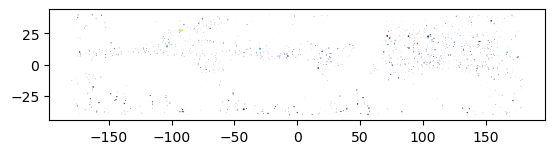

In [21]:
colocated_tracks.plot("max_precip")

In [24]:
colocated_tracks.to_parquet(
    "orcestra_coloc_ec.parquet",
)

In [4]:
colocated_tracks = gpd.read_parquet(
    "orcestra_coloc_ec.parquet",
)

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [19]:
colocated_tracks = colocated_tracks.set_geometry(colocated_tracks.geometry.buffer(0.1))

/tmp/ipykernel_124/581236434.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  colocated_tracks = colocated_tracks.set_geometry(colocated_tracks.geometry.buffer(0.1))


Text(0.5, 1.0, 'Max precip [mm/hr]')

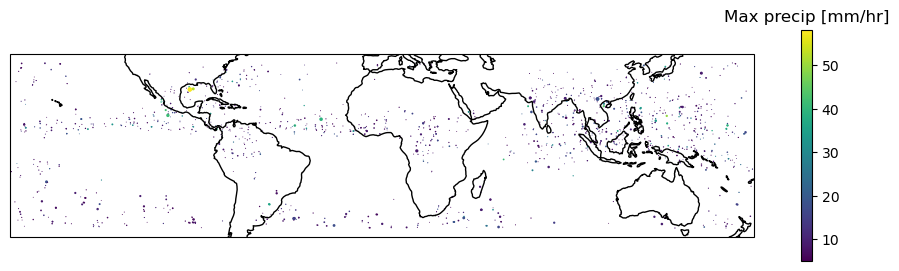

In [21]:
fig, ax = plt.subplots(subplot_kw=dict(projection=ccrs.PlateCarree()), figsize=(12,3))
ax.coastlines()

points = colocated_tracks.plot("max_precip", ax=ax, legend=True)
colorbar_ax = fig.axes[-1] #to get the last axis of the figure, it's the colorbar axes
colorbar_ax.set_title("Max precip [mm/hr]")


In [16]:
list(ax.artists)

[]

In [ ]:
ax.